In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('Crop_Recommendation.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nCrop Distribution:")
print(df['Crop'].value_counts())

Dataset Shape: (2200, 8)

First 5 rows:
   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        90          42         43    20.879744  82.002744  6.502985   
1        85          58         41    21.770462  80.319644  7.038096   
2        60          55         44    23.004459  82.320763  7.840207   
3        74          35         40    26.491096  80.158363  6.980401   
4        78          42         42    20.130175  81.604873  7.628473   

     Rainfall  Crop  
0  202.935536  Rice  
1  226.655537  Rice  
2  263.964248  Rice  
3  242.864034  Rice  
4  262.717340  Rice  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null  

In [4]:
# Data Preprocessing and Cleaning
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nNumber of duplicates: {df.duplicated().sum()}")

# Remove duplicates if any
df_clean = df.drop_duplicates()
print(f"Shape after removing duplicates: {df_clean.shape}")

# Check data types and unique values
print("\nData types:")
print(df_clean.dtypes)
print("\nNumber of unique crops:", df_clean['Crop'].nunique())
print("Unique crops:", df_clean['Crop'].unique())

Missing values in each column:
Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64

Number of duplicates: 0
Shape after removing duplicates: (2200, 8)

Data types:
Nitrogen         int64
Phosphorus       int64
Potassium        int64
Temperature    float64
Humidity       float64
pH_Value       float64
Rainfall       float64
Crop               str
dtype: object

Number of unique crops: 22
Unique crops: <ArrowStringArray>
[       'Rice',       'Maize',    'ChickPea', 'KidneyBeans',  'PigeonPeas',
   'MothBeans',    'MungBean',   'Blackgram',      'Lentil', 'Pomegranate',
      'Banana',       'Mango',      'Grapes',  'Watermelon',   'Muskmelon',
       'Apple',      'Orange',      'Papaya',     'Coconut',      'Cotton',
        'Jute',      'Coffee']
Length: 22, dtype: str


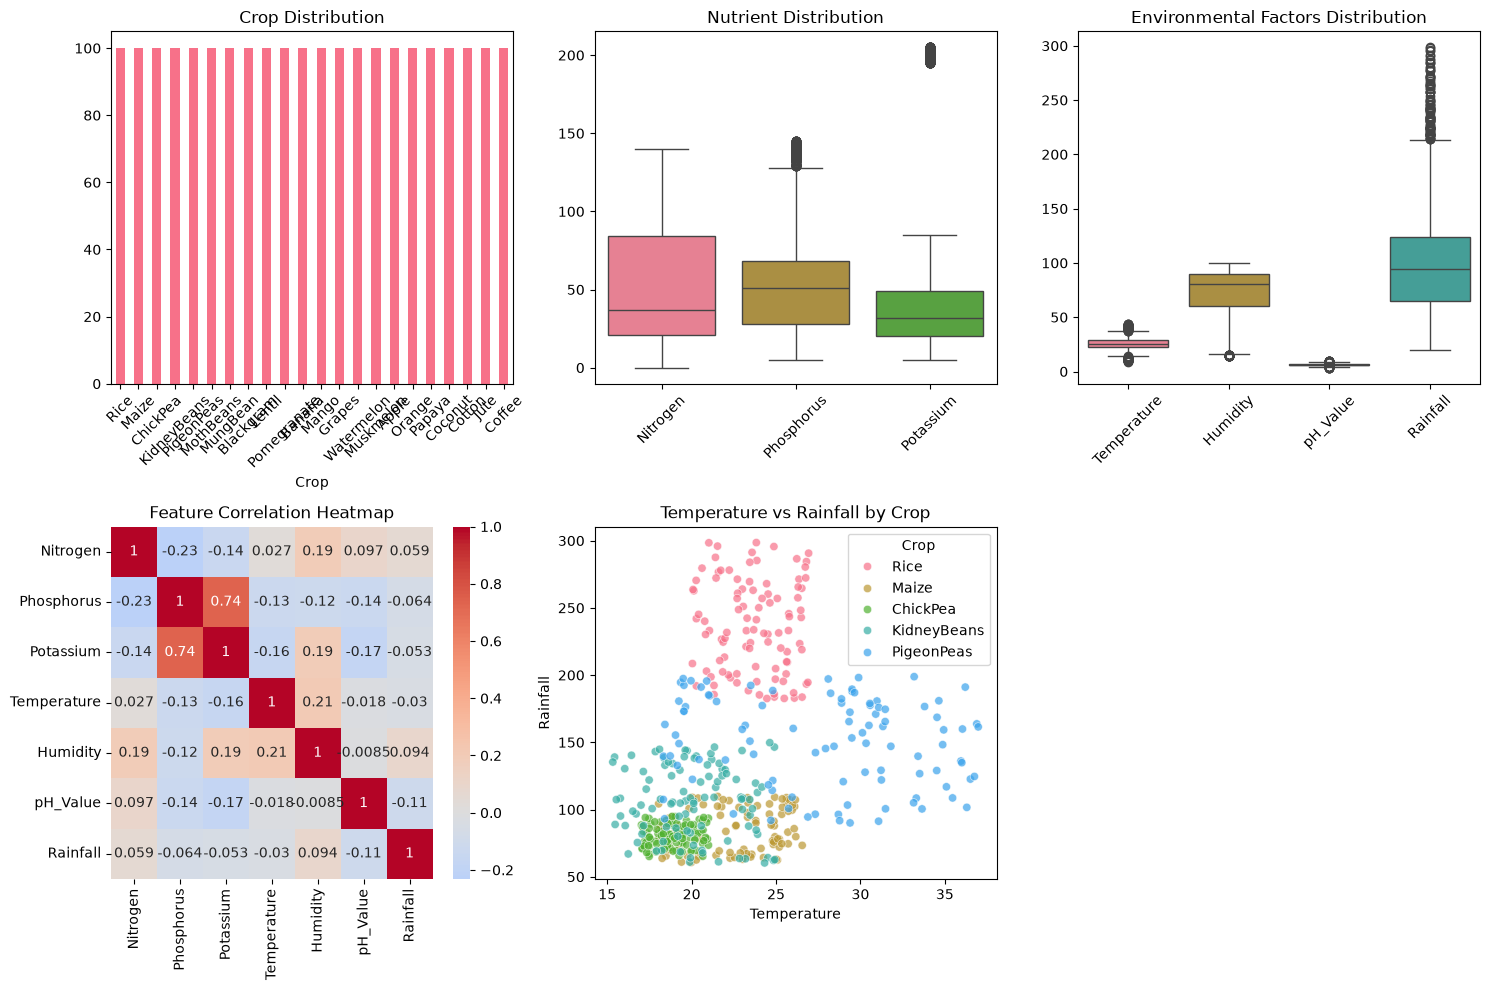

In [5]:
#  Data Visualization
# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# 5.1 Crop Distribution
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
df['Crop'].value_counts().plot(kind='bar')
plt.title('Crop Distribution')
plt.xticks(rotation=45)

# 5.2 Nutrient Distribution
plt.subplot(2, 3, 2)
sns.boxplot(data=df[['Nitrogen', 'Phosphorus', 'Potassium']])
plt.title('Nutrient Distribution')
plt.xticks(rotation=45)

# 5.3 Environmental Factors
plt.subplot(2, 3, 3)
sns.boxplot(data=df[['Temperature', 'Humidity', 'pH_Value', 'Rainfall']])
plt.title('Environmental Factors Distribution')
plt.xticks(rotation=45)

# 5.4 Correlation Heatmap
plt.subplot(2, 3, 4)
numeric_cols = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')

# 5.5 Pairplot for top 5 crops
plt.subplot(2, 3, 5)
top_crops = df['Crop'].value_counts().head(5).index
df_top = df[df['Crop'].isin(top_crops)]
sns.scatterplot(data=df_top, x='Temperature', y='Rainfall', hue='Crop', alpha=0.7)
plt.title('Temperature vs Rainfall by Crop')

plt.tight_layout()
plt.show()

# 5.6 Interactive Plotly Visualizations
# Nutrient levels by crop
fig = px.box(df, x='Crop', y='Nitrogen', title='Nitrogen Levels by Crop')
fig.show()

# 3D Scatter plot
fig = px.scatter_3d(df, x='Nitrogen', y='Phosphorus', z='Potassium', 
                   color='Crop', title='3D Nutrient Analysis')
fig.show()

# Environmental conditions by crop
fig = px.scatter(df, x='Temperature', y='Humidity', color='Crop', 
                size='Rainfall', title='Temperature vs Humidity by Crop')
fig.show()

In [6]:
#Feature Engineering and Preprocessing
print("FEATURE ENGINEERING AND PREPROCESSING")
print("="*50)

# Encode the target variable
label_encoder = LabelEncoder()
df_clean['Crop_encoded'] = label_encoder.fit_transform(df_clean['Crop'])

print("Label Encoding Mapping:")
for i, crop in enumerate(label_encoder.classes_):
    print(f"  {crop}: {i}")

# Prepare features and target
X = df_clean[['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']]
y = df_clean['Crop_encoded']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")
print(f"Scaled training data shape: {X_train_scaled.shape}")

FEATURE ENGINEERING AND PREPROCESSING
Label Encoding Mapping:
  Apple: 0
  Banana: 1
  Blackgram: 2
  ChickPea: 3
  Coconut: 4
  Coffee: 5
  Cotton: 6
  Grapes: 7
  Jute: 8
  KidneyBeans: 9
  Lentil: 10
  Maize: 11
  Mango: 12
  MothBeans: 13
  MungBean: 14
  Muskmelon: 15
  Orange: 16
  Papaya: 17
  PigeonPeas: 18
  Pomegranate: 19
  Rice: 20
  Watermelon: 21

Feature matrix shape: (2200, 7)
Target vector shape: (2200,)

Training set size: (1760, 7)
Test set size: (440, 7)

Feature scaling completed!
Scaled training data shape: (1760, 7)


MACHINE LEARNING MODEL TRAINING
Training models...

✓ Random Forest          Accuracy: 0.9955
✓ Logistic Regression    Accuracy: 0.9727
✓ SVM                    Accuracy: 0.9841

MODEL COMPARISON
Random Forest          0.9955
SVM                    0.9841
Logistic Regression    0.9727

🏆 Best Model: Random Forest  (accuracy = 0.9955)

DETAILED EVALUATION OF BEST MODEL

Random Forest — Accuracy: 0.9955
------------------------------------------------------------
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        20
      Banana       1.00      1.00      1.00        20
   Blackgram       1.00      0.95      0.97        20
    ChickPea       1.00      1.00      1.00        20
     Coconut       1.00      1.00      1.00        20
      Coffee       1.00      1.00      1.00        20
      Cotton       1.00      1.00      1.00        20
      Grapes       1.00      1.00      1.00        20
        Jute       0.95      1.00      0.98    

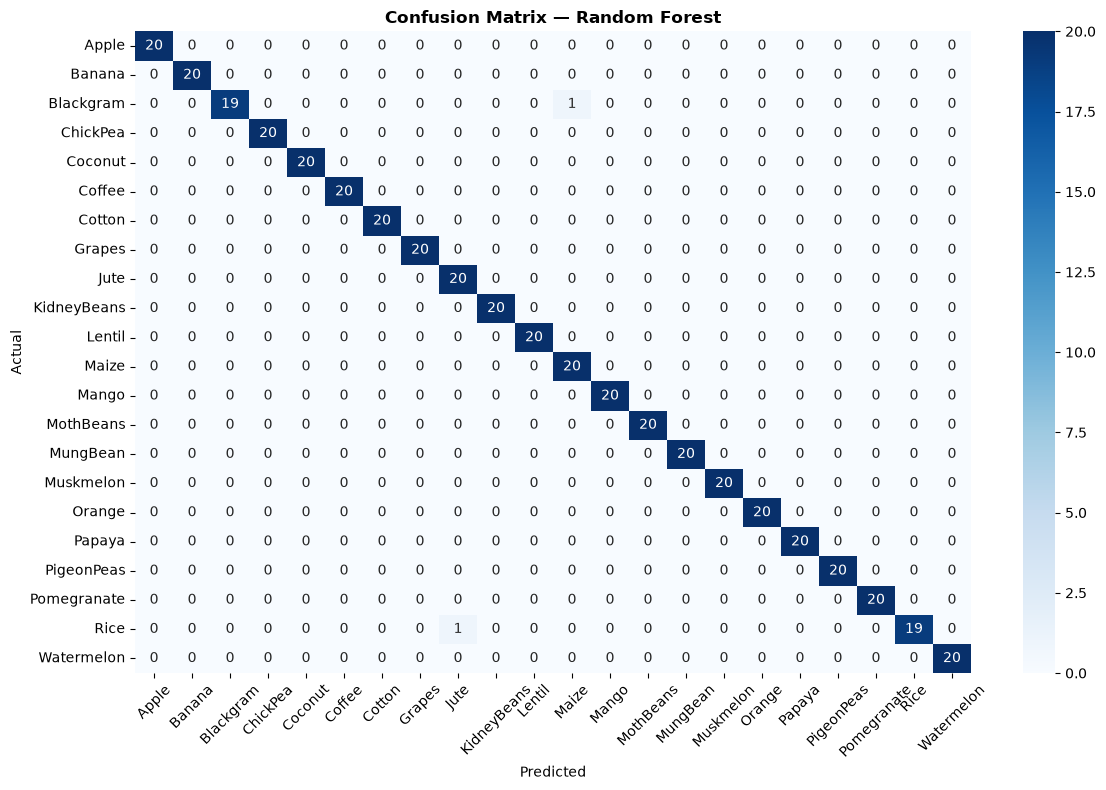

In [7]:
# ============================================================
# MACHINE LEARNING — TRAIN & COMPARE MODELS
# ============================================================
print("MACHINE LEARNING MODEL TRAINING")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Helper: evaluate a model and (optionally) plot confusion matrix
# ------------------------------------------------------------
def evaluate_model(model, X_eval, y_true, model_name, plot_cm=True):
    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{model_name} — Accuracy: {acc:.4f}")
    print("-" * 60)
    print(classification_report(y_true, y_pred,
                                target_names=label_encoder.classes_,
                                zero_division=0))

    if plot_cm:
        plt.figure(figsize=(12, 8))
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=label_encoder.classes_,
                    yticklabels=label_encoder.classes_)
        plt.title(f"Confusion Matrix — {model_name}", fontweight="bold")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    return acc

# ------------------------------------------------------------
# Models to train
# ------------------------------------------------------------
models = {
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, random_state=42),
        "use_scaled": False,
    },
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "use_scaled": True,
    },
    "SVM": {
        "model": SVC(random_state=42, probability=True),
        "use_scaled": True,
    },
}

best_accuracy = 0
best_model = None
best_model_name = ""
best_use_scaled = False
results = {}

# ------------------------------------------------------------
# Train loop
# ------------------------------------------------------------
print("Training models...\n")

for model_name, info in models.items():
    model = info["model"]
    use_scaled = info["use_scaled"]

    if use_scaled:
        model.fit(X_train_scaled, y_train)
        X_eval = X_test_scaled
    else:
        model.fit(X_train, y_train)
        X_eval = X_test

    acc = accuracy_score(y_test, model.predict(X_eval))
    results[model_name] = acc
    print(f"✓ {model_name:<22} Accuracy: {acc:.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = model_name
        best_use_scaled = use_scaled

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name:<22} {acc:.4f}")

print(f"\n🏆 Best Model: {best_model_name}  (accuracy = {best_accuracy:.4f})")

# ------------------------------------------------------------
# Detailed evaluation of the best model
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("DETAILED EVALUATION OF BEST MODEL")
print("=" * 60)
if best_use_scaled:
    evaluate_model(best_model, X_test_scaled, y_test, best_model_name)
else:
    evaluate_model(best_model, X_test, y_test, best_model_name)

In [8]:
# Save Model Only
import joblib

print("SAVING MODEL AND ARTIFACTS")
print("="*50)

# Create a dictionary with all necessary objects
model_artifacts = {
    'model': best_model,
    'scaler': scaler,
    'label_encoder': label_encoder,
    'feature_names': X.columns.tolist(),
    'use_scaled': best_use_scaled,
    'model_name': best_model_name,
    'accuracy': best_accuracy,
    'crop_classes': label_encoder.classes_.tolist()
}

# Save the artifacts
joblib.dump(model_artifacts, 'crop_recommendation_model.pkl')

print("✅ Model and artifacts saved successfully as 'crop_recommendation_model.pkl'")
print(f"Best Model: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"Number of crops: {len(label_encoder.classes_)}")

SAVING MODEL AND ARTIFACTS
✅ Model and artifacts saved successfully as 'crop_recommendation_model.pkl'
Best Model: Random Forest
Accuracy: 0.9955
Number of crops: 22
